In [4]:
import goes2go
import pandas as pd
import numpy as np
import xarray as xr
from goes2go import GOES
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

import warnings
warnings.simplefilter("ignore")

import fsspec
fs = fsspec.filesystem('s3', anon=True)
fsspec_caching = {
    "cache_type": "blockcache",  # block cache stores blocks of fixed size and uses eviction using a LRU strategy.
    "block_size": 8
    * 1024
    * 1024,  # size in bytes per block, adjust depends on the file size but the recommended size is in the MB
}

from pyproj import Proj

GOES_EAST_PROJ4 = "+proj=geos +lon_0=-75 +h=35786023 +x_0=0 +y_0=0 +sweep=x +datum=WGS84 +units=m +no_defs"

goes_satellite_height = 35786023  # in meters
goes_satellite_longitude = -75  # in degrees
goes_satellite_latitude = 0  # in degrees

Products to download

- Cloud Height (2 km): ACHA, variable HT
- Cloud Optical Depth (2 km): COD, variable COD
- Cloud Masks (2 km): ACM, variables BCM and ACM
- Cloud Particle Size (2 km): CPS, variables PSD 
- Cloud Top Temperature (2 km): ACHT, variable TEMP
- Cloud Top Phase (2 km): ACTP, variable Phase
- Cloud Pressure (2 km): ACHP, variable PRES

In [ ]:
path = './additional-variables/pretraining-test-goes-[2024].csv'
df = pd.read_csv(path)

In [6]:
df.head()

,Unnamed: 0,cloud3d:patch_id,geometry,cloud3d:satellite,geoenrich:admin_countries,geoenrich:elevation,geoenrich:precipitation,geoenrich:temperature,geotiff:stats,majortom:code,...,stac:time_end,tiff:header,internal:current_id,bbox,satellite,_base,date,month,lon,lat
0,41244,20240128001020_3506_2509,b'\x01\x01\x00\x00\x00X\x16\xe7S\x804G\xc08m\x...,GOES,Brazil,83.038414,1.938610,299.50076,"[array([0.0000000e+00, 3.0517578e-02, 1.699663...",1000km_0001D_0006L,...,2024-01-28 00:19:51.900,"b""LOVE\x01\x00\x00\x02\x00\x00\x00\x02\x00\x00...",41244,"{'xmin': -46.41016625197943, 'ymin': -2.871913...",GOES,https://data.source.coop/taco/3dclouds/pretrai...,2024-01-28 00:10:20.500,2024-01,-46.410166,-2.871913
1,42832,20240128013020_3226_2374,b'\x01\x01\x00\x00\x00\xbe\x84\xc2\xbbt2J\xc0\...,GOES,Brazil,181.491730,1.517897,299.34265,"[array([0.0000000e+00, 6.1035156e-02, 2.444721...",1000km_0001D_0006L,...,2024-01-28 01:39:51.800,"b""LOVE\x01\x00\x00\x02\x00\x00\x00\x02\x00\x00...",42832,"{'xmin': -52.39418742177939, 'ymin': -0.367331...",GOES,https://data.source.coop/taco/3dclouds/pretrai...,2024-01-28 01:30:20.500,2024-01,-52.394187,-0.367331
2,12624,20240128014020_1376_2308,b'\x01\x01\x00\x00\x00<d*\xa5\x95\xafU\xc0C:\t...,GOES,Ocean/Sea/Lakes,0.000000,0.450487,297.18726,"[array([0.0000000e+00, 3.0517578e-02, 1.769512...",1000km_0000U_0010L,...,2024-01-28 01:49:52.400,b'LOVE\x01\x00\x00\x02\x00\x00\x00\x02\x00\x00...,12624,"{'xmin': -86.743508616827, 'ymin': 0.835727790...",GOES,https://data.source.coop/taco/3dclouds/pretrai...,2024-01-28 01:40:20.500,2024-01,-86.743509,0.835728
3,11716,20240128021020_1463_2567,b'\x01\x01\x00\x00\x00\x01l\xd0\xb2\x14JU\xc0k...,GOES,Ocean/Sea/Lakes,0.000000,0.302728,295.66020,"[array([0.0000000e+00, 3.0517578e-02, 1.420266...",1000km_0001D_0010L,...,2024-01-28 02:19:51.900,b'LOVE\x01\x00\x00\x02\x00\x00\x00\x02\x00\x00...,11716,"{'xmin': -85.15751333574009, 'ymin': -3.875641...",GOES,https://data.source.coop/taco/3dclouds/pretrai...,2024-01-28 02:10:20.500,2024-01,-85.157513,-3.875642
4,42351,20240128024020_3379_2675,b'\x01\x01\x00\x00\x00j\x18\xb3\xea9\x83H\xc0\...,GOES,Brazil,148.532780,1.789909,299.51993,"[array([0.0000000e+00, 3.0517578e-02, 1.909211...",1000km_0001D_0006L,...,2024-01-28 02:49:51.300,"b""LOVE\x01\x00\x00\x02\x00\x00\x00\x02\x00\x00...",42351,"{'xmin': -49.02520498032466, 'ymin': -5.938364...",GOES,https://data.source.coop/taco/3dclouds/pretrai...,2024-01-28 02:40:20.500,2024-01,-49.025205,-5.938364


In [7]:
test_file = df.iloc[100]
print(test_file)

Unnamed: 0                                                               28828
cloud3d:patch_id                                      20240228221020_1767_1525
geometry                     b'\x01\x01\x00\x00\x00\xcdT\x94\x82)\xf2S\xc0\...
cloud3d:satellite                                                         GOES
geoenrich:admin_countries                                      Ocean/Sea/Lakes
geoenrich:elevation                                                        0.0
geoenrich:precipitation                                               1.243478
geoenrich:temperature                                                299.98697
geotiff:stats                [array([  3.78125  ,  41.25     ,   5.7463937,...
majortom:code                                               1000km_0001U_0009L
stac:crs                     PROJCS["unknown",GEOGCS["unknown",DATUM["Unkno...
stac:geotransform            [-1.0220485e+06  2.0039375e+03  0.0000000e+00 ...
stac:tensor_shape                                   

#### Find all files between launch of satellite and now

We need to write a loop around this, since the goes2go searching across long time periods is pretty slow. I also noticed that `goes2go.goes_nearesttime` takes way longer than searching for a timerange.

In [1]:
def check_time_in_range(dt, query_dt, delta_minutes=2):
    start_dt = query_dt - timedelta(minutes=delta_minutes)
    end_dt = query_dt + timedelta(minutes=delta_minutes)
    return start_dt <= dt <= end_dt

def get_correct_file(files, query_dt):
    if len(files) == 0:
        return None
    else:
        files['diff'] = abs(pd.to_datetime(files['start']) - query_dt)
        correct_file = files.loc[files['diff'].idxmin()]
        if check_time_in_range(pd.to_datetime(correct_file['start']), query_dt):
            return correct_file['file']
        else:
            return None

In [8]:
abi_files = goes2go.goes_timerange(
    satellite='noaa-goes16',
    start=pd.to_datetime(test_file['date']) - timedelta(minutes=10), 
    end=pd.to_datetime(test_file['date']) + timedelta(minutes=10),
    download=False,
    domain='F',
    product="ABI-L2-MCMIP",
)

abi_files['diff'] = abs(abi_files['start'] - pd.to_datetime(test_file['date']))

In [10]:
abi_file = get_correct_file(abi_files, pd.to_datetime(test_file['date']))
abi_file

'noaa-goes16/ABI-L2-MCMIPF/2024/059/22/OR_ABI-L2-MCMIPF-M6_G16_s20240592210206_e20240592219527_c20240592220004.nc'

#### Other Data Products

In [11]:
# Cloud height at 2 km

acha_files = goes2go.goes_timerange(
    satellite='noaa-goes16',
    start=pd.to_datetime(test_file['date']) - timedelta(minutes=10), 
    end=pd.to_datetime(test_file['date']) + timedelta(minutes=10),
    download=False,
    # domain='F',
    product="ABI-L2-ACHA2KMF",
)

acha_file = get_correct_file(acha_files, pd.to_datetime(test_file['date']))
acha_file

'noaa-goes16/ABI-L2-ACHA2KMF/2024/059/22/OR_ABI-L2-ACHA2KMF-M6_G16_s20240592210206_e20240592219514_c20240592223124.nc'

In [13]:
# Cloud pressure at 2 km

achp_files = goes2go.goes_timerange(
    satellite='noaa-goes16',
    start=pd.to_datetime(test_file['date']) - timedelta(minutes=10), 
    end=pd.to_datetime(test_file['date']) + timedelta(minutes=10),
    download=False,
    # domain='F',
    product="ABI-L2-ACHP2KMF",
)
achp_file = get_correct_file(achp_files, pd.to_datetime(test_file['date']))
achp_file

'noaa-goes16/ABI-L2-ACHP2KMF/2024/059/22/OR_ABI-L2-ACHP2KMF-M6_G16_s20240592210206_e20240592219514_c20240592223123.nc'

In [14]:
# Cloud optical depth at 2 km

cod_files = goes2go.goes_timerange(
    satellite='noaa-goes16',
    start=pd.to_datetime(test_file['date']) - timedelta(minutes=10), 
    end=pd.to_datetime(test_file['date']) + timedelta(minutes=10),
    download=False,
    # domain='F',
    product="ABI-L2-COD2KMF",
)

cod_file = get_correct_file(cod_files, pd.to_datetime(test_file['date']))
cod_file

'noaa-goes16/ABI-L2-COD2KMF/2024/059/22/OR_ABI-L2-COD2KMF-M6_G16_s20240592210206_e20240592219514_c20240592224351.nc'

In [15]:
# Cloud temperature at 2 km

acht_files = goes2go.goes_timerange(
    satellite='noaa-goes16',
    start=pd.to_datetime(test_file['date']) - timedelta(minutes=10), 
    end=pd.to_datetime(test_file['date']) + timedelta(minutes=10),
    download=False,
    # domain='F',
    product="ABI-L2-ACHTF",
)
acht_file = get_correct_file(acht_files, pd.to_datetime(test_file['date']))
acht_file

'noaa-goes16/ABI-L2-ACHTF/2024/059/22/OR_ABI-L2-ACHTF-M6_G16_s20240592210206_e20240592219514_c20240592223121.nc'

In [16]:
# Clear sky mask at 2 km

acm_files = goes2go.goes_timerange(
    satellite='noaa-goes16',
    start=pd.to_datetime(test_file['date']) - timedelta(minutes=10), 
    end=pd.to_datetime(test_file['date']) + timedelta(minutes=10),
    download=False,
    # domain='F',
    product="ABI-L2-ACMF",
)
acm_file = get_correct_file(acm_files, pd.to_datetime(test_file['date']))
acm_file

'noaa-goes16/ABI-L2-ACMF/2024/059/22/OR_ABI-L2-ACMF-M6_G16_s20240592210206_e20240592219514_c20240592220324.nc'

In [17]:
# Cloud phase at 2 km

actp_files = goes2go.goes_timerange(
    satellite='noaa-goes16',
    start=pd.to_datetime(test_file['date']) - timedelta(minutes=10), 
    end=pd.to_datetime(test_file['date']) + timedelta(minutes=10),
    download=False,
    # domain='F',
    product="ABI-L2-ACTPF",
)
actp_file = get_correct_file(actp_files, pd.to_datetime(test_file['date']))
actp_file

'noaa-goes16/ABI-L2-ACTPF/2024/059/22/OR_ABI-L2-ACTPF-M6_G16_s20240592210206_e20240592219514_c20240592221095.nc'

In [18]:
# Cloud particle size at 2 km

cps_files = goes2go.goes_timerange(
    satellite='noaa-goes16',
    start=pd.to_datetime(test_file['date']) - timedelta(minutes=10), 
    end=pd.to_datetime(test_file['date']) + timedelta(minutes=10),
    download=False,
    # domain='F',
    product="ABI-L2-CPSF",
)
cps_file = get_correct_file(cps_files, pd.to_datetime(test_file['date']))
cps_file

'noaa-goes16/ABI-L2-CPSF/2024/059/22/OR_ABI-L2-CPSF-M6_G16_s20240592210206_e20240592219514_c20240592224355.nc'

#### Open example file

In [19]:
def get_goes_image(
    file: str,)-> xr.Dataset:
    """
    Get the GOES image for a given timestamp.
    
    Args:
        file (str): The path to the GOES image.
    
    Returns:
        xr.Dataset: The GOES dataset for the specified timestamp.
    """
    # Create filesystem object inside worker process to avoid fork-safety issues
    fs = fsspec.filesystem('s3', anon=True)
    fsspec_caching = {
        "cache_type": "blockcache",  # block cache stores blocks of fixed size and uses eviction using a LRU strategy.
        "block_size": 8 * 1024 * 1024 # size in bytes per block, adjust depends on the file size but the recommended size is in the MB}
    }
    ds = xr.open_dataset(fs.open(file, **fsspec_caching), engine="h5netcdf")
    return ds

def get_goes_patch(
    lat: float, lon: float, dataset: xr.Dataset, patch_size: int
) -> xr.Dataset:
    """
    Get a patch of GOES data centered around a given latitude and longitude.
    """
    x, y = get_abi_x_y(np.array([lat]), np.array([lon]), dataset)
    x_dif = dataset.x.diff('x').values[0]
    y_dif = dataset.y.diff('y').values[0]
    return dataset.sel(
       x=slice(x[0] - (abs(x_dif) * patch_size / 2), x[0] + (abs(x_dif) * patch_size / 2)),
      y=slice(y[0] + (abs(y_dif) * patch_size / 2), y[0] - (abs(y_dif) * patch_size / 2)),
    )

def get_abi_x_y(
    lat: np.ndarray, lon: np.ndarray, dataset: xr.Dataset
) -> tuple[np.ndarray, np.ndarray]:
    """
    Get the x, y coordinates in the ABI projection for given latitudes and
        longitudes
    """
    p = get_abi_proj(dataset)
    x, y = p(lon, lat)
    return (
        x / dataset.goes_imager_projection.perspective_point_height,
        y / dataset.goes_imager_projection.perspective_point_height,
    )

def get_abi_proj(dataset: xr.Dataset) -> Proj:
    """
    Return a pyproj projection from the information contained within an ABI file
    """
    return Proj(
        proj="geos",
        h=dataset.goes_imager_projection.perspective_point_height,
        lon_0=dataset.goes_imager_projection.longitude_of_projection_origin,
        lat_0=dataset.goes_imager_projection.latitude_of_projection_origin,
        sweep=dataset.goes_imager_projection.sweep_angle_axis,
    )

In [55]:
ds = get_goes_image(file=abi_file)

In [22]:
lat = test_file['lat']
lon = test_file['lon']

ds_patch = get_goes_patch(lat, lon, ds, 256)

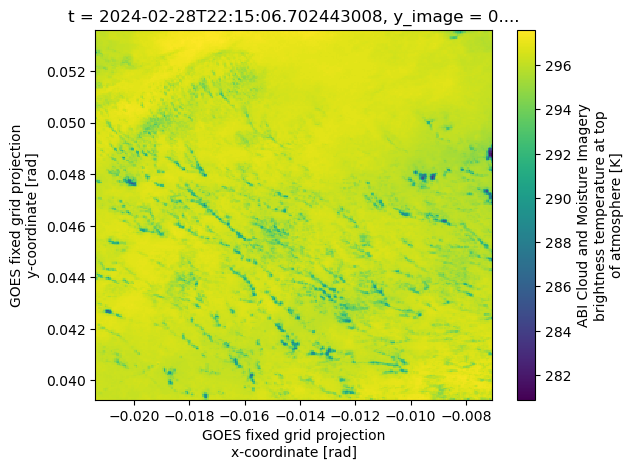

In [23]:
ds_patch.CMI_C14.plot()

In [70]:
file_ = achp_file

ds_ = get_goes_image(file=file_)
lat = test_file['lat']
lon = test_file['lon']

ds_patch_ = get_goes_patch(lat, lon, ds_, 256)

In [71]:
ds_

<xarray.Dataset> Size: 235MB
Dimensions:                                 (y: 5424, x: 5424,
                                             number_of_time_bounds: 2,
                                             number_of_image_bounds: 2,
                                             number_of_LZA_bounds: 2,
                                             number_of_SZA_bounds: 2)
Coordinates:
  * y                                       (y) float32 22kB 0.1518 ... -0.1518
  * x                                       (x) float32 22kB -0.1518 ... 0.1518
    t                                       datetime64[ns] 8B ...
    y_image                                 float32 4B ...
    x_image                                 float32 4B ...
    local_zenith_angle                      float32 4B ...
    solar_zenith_angle                      float32 4B ...
Dimensions without coordinates: number_of_time_bounds, number_of_image_bounds,
                                number_of_LZA_bounds, number_of_SZA_bounds
Data variables: (12/24)
    PRES                                    (y, x) float32 118MB ...
    DQF                                     (y, x) float32 118MB ...
    time_bounds                             (number_of_time_bounds) datetime64[ns] 16B ...
    goes_imager_projection                  int32 4B ...
    y_image_bounds                          (number_of_image_bounds) float32 8B ...
    x_image_bounds                          (number_of_image_bounds) float32 8B ...
    ...                                      ...
    solar_zenith_angle_bounds               (number_of_SZA_bounds) float32 8B ...
    algorithm_dynamic_input_data_container  int32 4B ...
    processing_parm_version_container       int32 4B ...
    algorithm_product_version_container     int32 4B ...
    percent_uncorrectable_GRB_errors        float32 4B ...
    percent_uncorrectable_L0_errors         float32 4B ...
Attributes: (12/29)
    naming_authority:          gov.nesdis.noaa
    Conventions:               CF-1.7
    Metadata_Conventions:      Unidata Dataset Discovery v1.0
    standard_name_vocabulary:  CF Standard Name Table (v35, 20 July 2016)
    institution:               DOC/NOAA/NESDIS > U.S. Department of Commerce,...
    project:                   GOES
    ...                        ...
    date_created:              2024-02-28T22:23:12.3Z
    time_coverage_start:       2024-02-28T22:10:20.6Z
    time_coverage_end:         2024-02-28T22:19:51.4Z
    timeline_id:               ABI Mode 6
    production_data_source:    Realtime
    id:                        d5cb9b9c-2608-4100-96da-cf3bbcab011b

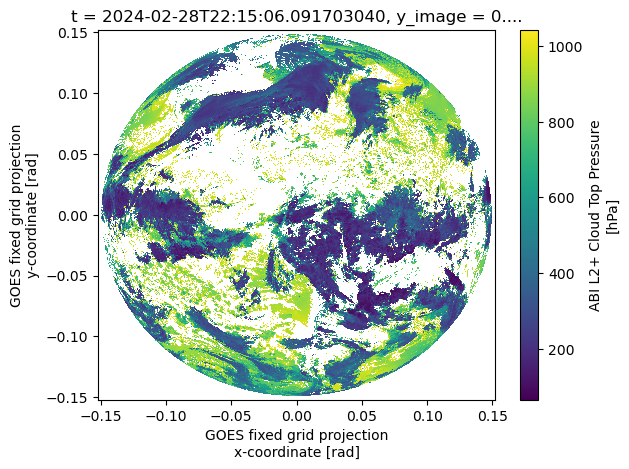

In [72]:
ds_.PRES.plot()

In [44]:
df_add = pd.read_csv('./additional-variables/pretraining-test-goes-[2024]-with-additional-variables.csv')

In [38]:
np.sum(df_add['all_available'])

np.int64(951)

In [45]:
df_add.head()

,Unnamed: 0,cloud3d:patch_id,geometry,cloud3d:satellite,geoenrich:admin_countries,geoenrich:elevation,geoenrich:precipitation,geoenrich:temperature,geotiff:stats,majortom:code,...,lat,abi_file,acha_file,achp_file,cod_file,acht_file,acm_file,actp_file,cps_file,all_available
0,41244,20240128001020_3506_2509,b'\x01\x01\x00\x00\x00X\x16\xe7S\x804G\xc08m\x...,GOES,Brazil,83.038414,1.938610,299.50076,"[array([0.0000000e+00, 3.0517578e-02, 1.699663...",1000km_0001D_0006L,...,-2.871913,noaa-goes16/ABI-L1b-RadC/2024/028/00/OR_ABI-L1...,noaa-goes16/ABI-L2-ACHA2KMF/2024/028/00/OR_ABI...,noaa-goes16/ABI-L2-ACHP2KMF/2024/028/00/OR_ABI...,noaa-goes16/ABI-L2-COD2KMF/2024/028/00/OR_ABI-...,noaa-goes16/ABI-L2-ACHTF/2024/028/00/OR_ABI-L2...,noaa-goes16/ABI-L2-ACMF/2024/028/00/OR_ABI-L2-...,noaa-goes16/ABI-L2-ACTPF/2024/028/00/OR_ABI-L2...,noaa-goes16/ABI-L2-CPSF/2024/028/00/OR_ABI-L2-...,True
1,42832,20240128013020_3226_2374,b'\x01\x01\x00\x00\x00\xbe\x84\xc2\xbbt2J\xc0\...,GOES,Brazil,181.491730,1.517897,299.34265,"[array([0.0000000e+00, 6.1035156e-02, 2.444721...",1000km_0001D_0006L,...,-0.367331,noaa-goes16/ABI-L1b-RadC/2024/028/01/OR_ABI-L1...,noaa-goes16/ABI-L2-ACHA2KMF/2024/028/01/OR_ABI...,noaa-goes16/ABI-L2-ACHP2KMF/2024/028/01/OR_ABI...,noaa-goes16/ABI-L2-COD2KMF/2024/028/01/OR_ABI-...,noaa-goes16/ABI-L2-ACHTF/2024/028/01/OR_ABI-L2...,noaa-goes16/ABI-L2-ACMF/2024/028/01/OR_ABI-L2-...,noaa-goes16/ABI-L2-ACTPF/2024/028/01/OR_ABI-L2...,noaa-goes16/ABI-L2-CPSF/2024/028/01/OR_ABI-L2-...,True
2,12624,20240128014020_1376_2308,b'\x01\x01\x00\x00\x00<d*\xa5\x95\xafU\xc0C:\t...,GOES,Ocean/Sea/Lakes,0.000000,0.450487,297.18726,"[array([0.0000000e+00, 3.0517578e-02, 1.769512...",1000km_0000U_0010L,...,0.835728,noaa-goes16/ABI-L1b-RadC/2024/028/01/OR_ABI-L1...,noaa-goes16/ABI-L2-ACHA2KMF/2024/028/01/OR_ABI...,noaa-goes16/ABI-L2-ACHP2KMF/2024/028/01/OR_ABI...,noaa-goes16/ABI-L2-COD2KMF/2024/028/01/OR_ABI-...,noaa-goes16/ABI-L2-ACHTF/2024/028/01/OR_ABI-L2...,noaa-goes16/ABI-L2-ACMF/2024/028/01/OR_ABI-L2-...,noaa-goes16/ABI-L2-ACTPF/2024/028/01/OR_ABI-L2...,noaa-goes16/ABI-L2-CPSF/2024/028/01/OR_ABI-L2-...,True
3,11716,20240128021020_1463_2567,b'\x01\x01\x00\x00\x00\x01l\xd0\xb2\x14JU\xc0k...,GOES,Ocean/Sea/Lakes,0.000000,0.302728,295.66020,"[array([0.0000000e+00, 3.0517578e-02, 1.420266...",1000km_0001D_0010L,...,-3.875642,noaa-goes16/ABI-L1b-RadC/2024/028/02/OR_ABI-L1...,noaa-goes16/ABI-L2-ACHA2KMF/2024/028/02/OR_ABI...,noaa-goes16/ABI-L2-ACHP2KMF/2024/028/02/OR_ABI...,noaa-goes16/ABI-L2-COD2KMF/2024/028/02/OR_ABI-...,noaa-goes16/ABI-L2-ACHTF/2024/028/02/OR_ABI-L2...,noaa-goes16/ABI-L2-ACMF/2024/028/02/OR_ABI-L2-...,noaa-goes16/ABI-L2-ACTPF/2024/028/02/OR_ABI-L2...,noaa-goes16/ABI-L2-CPSF/2024/028/02/OR_ABI-L2-...,True
4,42351,20240128024020_3379_2675,b'\x01\x01\x00\x00\x00j\x18\xb3\xea9\x83H\xc0\...,GOES,Brazil,148.532780,1.789909,299.51993,"[array([0.0000000e+00, 3.0517578e-02, 1.909211...",1000km_0001D_0006L,...,-5.938364,noaa-goes16/ABI-L1b-RadC/2024/028/02/OR_ABI-L1...,noaa-goes16/ABI-L2-ACHA2KMF/2024/028/02/OR_ABI...,noaa-goes16/ABI-L2-ACHP2KMF/2024/028/02/OR_ABI...,noaa-goes16/ABI-L2-COD2KMF/2024/028/02/OR_ABI-...,noaa-goes16/ABI-L2-ACHTF/2024/028/02/OR_ABI-L2...,noaa-goes16/ABI-L2-ACMF/2024/028/02/OR_ABI-L2-...,noaa-goes16/ABI-L2-ACTPF/2024/028/02/OR_ABI-L2...,noaa-goes16/ABI-L2-CPSF/2024/028/02/OR_ABI-L2-...,True
